# Feature Engineering

1. Physics based features
2. Rolling/ Windows features
3. Interaction features
4. Machine type features
5. Threashold flags 
6. External context features

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#& to handle input file(s)
from pathlib import Path

In [2]:

#? csv file path (to resolve problem at production level)
BASE_DIR = Path().resolve().parent
df = pd.read_csv(BASE_DIR / 'Dataset' / 'ai4i2020_cleaned.csv')
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:

#^ copy of baseline features
df_feat = df.copy()

print("\nOriginal features:", df_feat.columns.tolist())
print("\nShape:", df_feat.shape)


Original features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Shape: (10000, 12)


# 1. Physical Features


In [4]:

#* power 
df_feat['power'] = df_feat['Torque [Nm]'] * df_feat['Rotational speed [rpm]']

#~ Heat stress (temp. difference)
df_feat['temp_diff'] = df_feat['Process temperature [K]'] - df_feat['Air temperature [K]']

#todo Wear rate (tool degradation per rotation)
df_feat['wear_rate'] = df_feat['Tool wear [min]'] / (df_feat['Rotational speed [rpm]'] + 1)

#? Torque / wear (stress on tool)
df_feat['torque_per_wear'] = df_feat['Torque [Nm]'] / (df_feat['Tool wear [min]'] + 1)

#& mechnical strain
df_feat['strain_index'] = df_feat['Torque [Nm]'] * df_feat['Tool wear [min]']

#^ efficiency : power per temprature
df_feat['power_per_temp'] = df_feat['power'] / df_feat['Process temperature [K]']

print("Physics features created!")
df_feat[['power','temp_diff','wear_rate','torque_per_wear','strain_index','power_per_temp']].describe()

Physics features created!


,power,temp_diff,wear_rate,torque_per_wear,strain_index,power_per_temp
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,59967.147040,10.000630,0.070918,1.324723,4314.664550,193.445095
std,10193.093881,1.001094,0.042590,4.735015,2826.567692,32.903588
min,10966.800000,7.600000,0.000000,0.026168,0.000000,35.606494
25%,53105.400000,9.300000,0.034520,0.239975,1963.650000,171.250988
50%,59883.900000,9.800000,0.069949,0.371277,4012.950000,193.124322
75%,66873.750000,11.000000,0.105608,0.735153,6279.000000,215.557913
max,99980.400000,12.100000,0.185273,68.500000,16497.000000,324.717116


In [5]:
df_feat.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,power,temp_diff,wear_rate,torque_per_wear,strain_index,power_per_temp
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,66382.8,10.5,0.000000,42.800000,0.0,215.109527
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,65190.4,10.5,0.002129,11.575000,138.9,211.177195
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,74001.2,10.4,0.003336,8.233333,247.0,239.874230
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,56603.5,10.4,0.004881,4.937500,276.5,183.420285
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,56320.0,10.5,0.006388,4.000000,360.0,182.442501


# 2. Rolling/ Windowa features

analyze trends by using rolling mean and std. deviations

In [6]:

#! Rolling window size
W_SHORT = 5
W_LONG  = 10

#? RPM rolling features
df_feat['rpm_rolling_mean'] = df_feat['Rotational speed [rpm]'].rolling(W_SHORT, min_periods=1).mean()
df_feat['rpm_rolling_std']  = df_feat['Rotational speed [rpm]'].rolling(W_SHORT, min_periods=1).std().fillna(0) 

#^ Torque 
df_feat['torque_rolling_mean'] = df_feat['Torque [Nm]'].rolling(W_SHORT, min_periods=1).mean()
df_feat['torque_rolling_std']  = df_feat['Torque [Nm]'].rolling(W_SHORT, min_periods=1).std().fillna(0)

#todo Temperature rolling features
df_feat['temp_rolling_mean'] = df_feat['Air temperature [K]'].rolling(W_SHORT, min_periods=1).mean()
df_feat['temp_rolling_std']  = df_feat['Air temperature [K]'].rolling(W_SHORT, min_periods=1).std().fillna(0)

#* Tool wear rolling (longer window — wear accumulates slowly)
df_feat['wear_rolling_mean'] = df_feat['Tool wear [min]'].rolling(W_LONG, min_periods=1).mean()

#& Power rolling 
df_feat['power_rolling_mean'] = df_feat['power'].rolling(W_SHORT, min_periods=1).mean()
df_feat['power_rolling_std']  = df_feat['power'].rolling(W_SHORT, min_periods=1).std().fillna(0)

print("Rolling features created!")
df_feat[['rpm_rolling_mean','torque_rolling_mean','power_rolling_mean','wear_rolling_mean']].describe()

Rolling features created!


,rpm_rolling_mean,torque_rolling_mean,power_rolling_mean,wear_rolling_mean
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,1538.774907,39.987646,59968.299790,107.943520
std,81.852540,4.535626,4621.690518,56.306599
min,1322.000000,23.820000,43669.640000,0.000000
25%,1481.800000,36.960000,56887.830000,59.300000
50%,1527.600000,39.940000,59931.370000,107.700000
75%,1581.200000,43.040000,63034.975000,156.000000
max,2004.400000,56.920000,77000.240000,240.700000


# 3. OUTLIER ANALYSIS
Finding outliers and handling them 

In [7]:
SENSOR_FEATURES = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

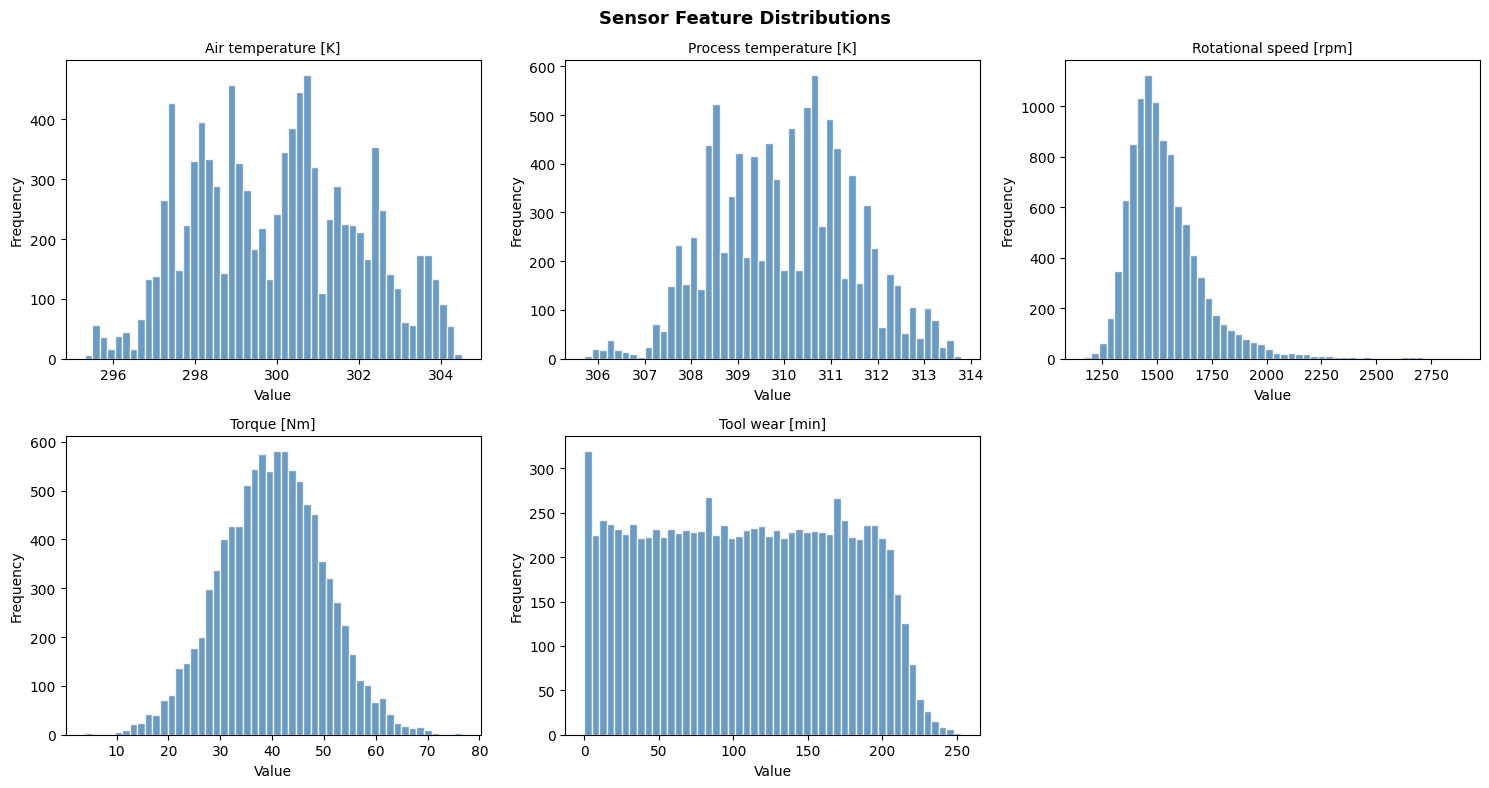

In [8]:
# Visualize distributions before applying any method
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(SENSOR_FEATURES):
    axes[i].hist(df_feat[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[5].axis('off')  # hide unused subplot
plt.suptitle('Sensor Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# IQR Method (primary — robust to skewed distributions)
iqr_flags = pd.DataFrame(index=df_feat.index)

for col in SENSOR_FEATURES:
    Q1 = df_feat[col].quantile(0.25)
    Q3 = df_feat[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_flags[f'{col}_iqr_outlier'] = ((df_feat[col] < lower) | (df_feat[col] > upper)).astype(int)
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={iqr_flags[f'{col}_iqr_outlier'].sum()}")

Air temperature [K]: lower=293.50, upper=306.30, outliers=0
Process temperature [K]: lower=305.35, upper=314.55, outliers=0
Rotational speed [rpm]: lower=1139.50, upper=1895.50, outliers=418
Torque [Nm]: lower=12.80, upper=67.20, outliers=69
Tool wear [min]: lower=-110.50, upper=325.50, outliers=0


In [10]:
#^ Z-Score Method (secondary — good for near-normal features like temp)
from scipy import stats

zscore_flags = pd.DataFrame(index=df_feat.index)

for col in SENSOR_FEATURES:
    z_scores = np.abs(stats.zscore(df_feat[col]))
    zscore_flags[f'{col}_zscore_outlier'] = (z_scores > 3).astype(int)
    print(f"{col}: outliers={zscore_flags[f'{col}_zscore_outlier'].sum()}")

Air temperature [K]: outliers=0
Process temperature [K]: outliers=0
Rotational speed [rpm]: outliers=164
Torque [Nm]: outliers=25
Tool wear [min]: outliers=0


In [11]:
print(df_feat['Machine failure'].value_counts(normalize=True))

failure_rate = df_feat['Machine failure'].mean()

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [12]:
#* Isolation Forest (multivariate — catches anomalous feature combinations)
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination = failure_rate,  
    random_state=42
)

iso_preds = iso_forest.fit_predict(df_feat[SENSOR_FEATURES])
df_feat['iso_forest_outlier'] = (iso_preds == -1).astype(int)

print(f"Isolation Forest outliers detected: {df_feat['iso_forest_outlier'].sum()}")

Isolation Forest outliers detected: 339


In [13]:
#& Merge IQR + Z-Score flags into df_feat
df_feat = pd.concat([df_feat, iqr_flags, zscore_flags], axis=1)

# Composite flags
df_feat['any_iqr_outlier']   = iqr_flags.max(axis=1)
df_feat['confirmed_outlier'] = pd.DataFrame({
    col: (iqr_flags[f'{col}_iqr_outlier'] & zscore_flags[f'{col}_zscore_outlier'])
    for col in SENSOR_FEATURES
}).max(axis=1).astype(int)

# Majority vote across all 3 methods
df_feat['outlier_vote'] = (
    df_feat['any_iqr_outlier'] +
    zscore_flags.max(axis=1).astype(int) +
    df_feat['iso_forest_outlier']
)
df_feat['final_outlier_flag'] = (df_feat['outlier_vote'] >= 2).astype(int)

print("All outlier flags merged into df_feat")
print(f"IQR (any feature):              {df_feat['any_iqr_outlier'].sum()}")
print(f"Confirmed (IQR + Z-Score both): {df_feat['confirmed_outlier'].sum()}")
print(f"Isolation Forest:               {df_feat['iso_forest_outlier'].sum()}")
print(f"Final flag (2/3 agree):         {df_feat['final_outlier_flag'].sum()}")

All outlier flags merged into df_feat
IQR (any feature):              459
Confirmed (IQR + Z-Score both): 178
Isolation Forest:               339
Final flag (2/3 agree):         221


In [14]:
#todo Critical check: do outliers correlate with actual machine failures?
for label, col in [
    ('IQR + Z-Score (confirmed)', 'confirmed_outlier'),
    ('Isolation Forest',          'iso_forest_outlier'),
    ('Final Flag (2/3 vote)',     'final_outlier_flag')
]:
    print(f"\n{label}:\n")
    print(pd.crosstab(
        df_feat[col],
        df_feat['Machine failure'],
        rownames=['Outlier'],
        colnames=['Machine Failure'],
        margins=True
    ))
    print("-" * 45)


IQR + Z-Score (confirmed):

Machine Failure     0    1    All
Outlier                          
0                9529  293   9822
1                 132   46    178
All              9661  339  10000
---------------------------------------------

Isolation Forest:

Machine Failure     0    1    All
Outlier                          
0                9379  282   9661
1                 282   57    339
All              9661  339  10000
---------------------------------------------

Final Flag (2/3 vote):

Machine Failure     0    1    All
Outlier                          
0                9494  285   9779
1                 167   54    221
All              9661  339  10000
---------------------------------------------


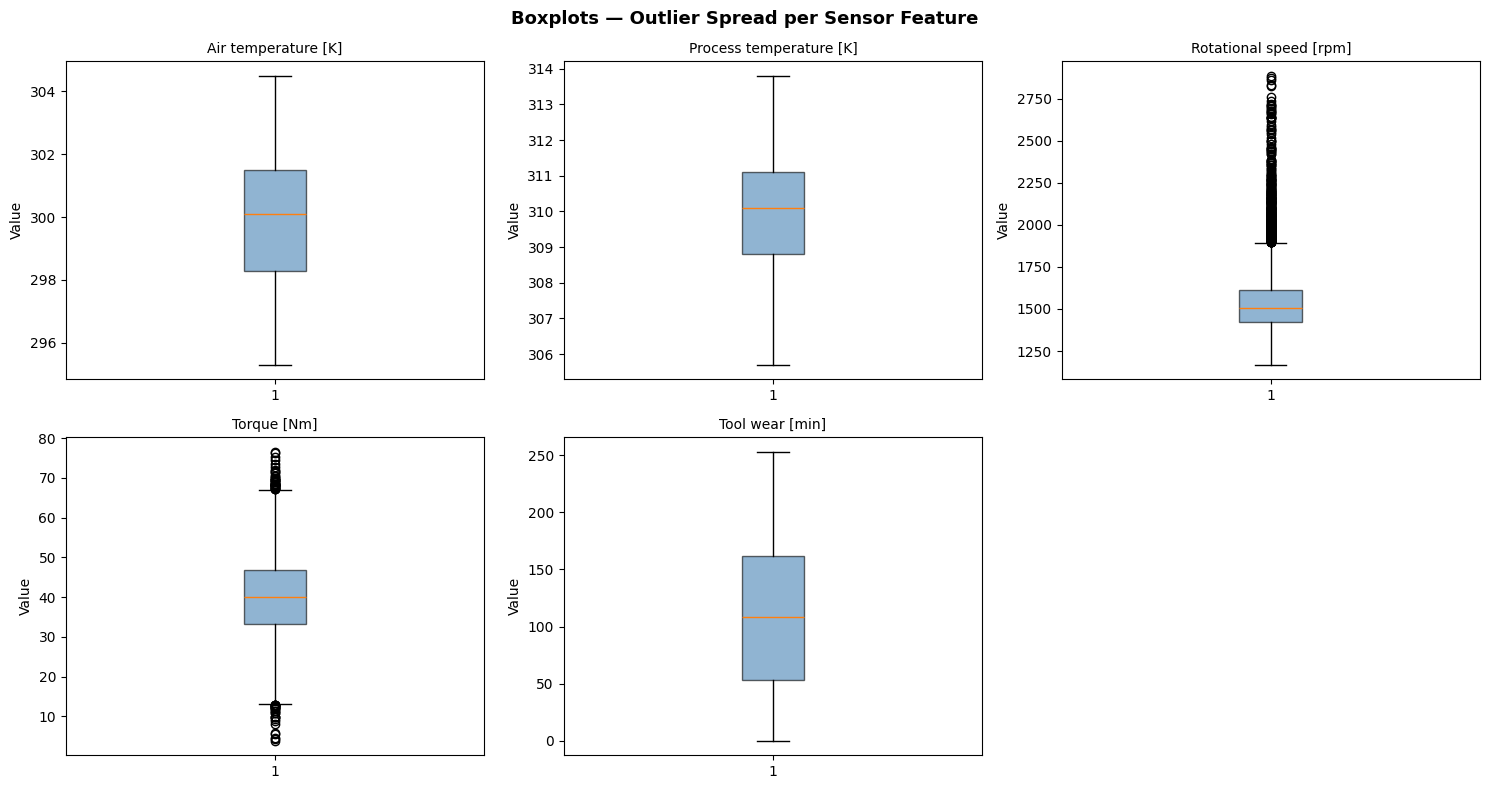

In [15]:
#^ Boxplots — outlier spread per sensor feature
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(SENSOR_FEATURES):
    axes[i].boxplot(df_feat[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')

axes[5].axis('off')
plt.suptitle('Boxplots — Outlier Spread per Sensor Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()